# 深度循环神经网络


## 简介
Deep RNN 堆叠多个 RNN 层，提供更多非线性性。

## 多层计算
在一个时间步里经过多个 RNN 层计算，第 $i$ 层的隐藏状态 $H_t^i$ 作为 $i+1$ 层的输入。

![drnn](./images/deep-rnn.svg)

$$H_t^1 = f_1(X_t, H_{t-1}^1)$$
$$H_t^i = f_i(H_t^{i-1}, H_{t-1}^i)$$
$$O_t = g(H_t^L)$$


## 实现


In [1]:
import torch
from torch import nn
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
batch_size = 32
num_steps = 35
train_iter, vocab = util.data.load_data_time_machine(batch_size, num_steps)

直接调 api，`num_layers` 指定层数。


In [5]:
vocab_size = len(vocab)
num_hiddens = 256
num_layers = 2
num_epochs = 100
lr = 1
device = util.try_gpu()

困惑度 3.7, 207868.2 token/秒
time traveller stood and the story of the some of the sole of the
traveller pating the sound of the some of the sole of the st


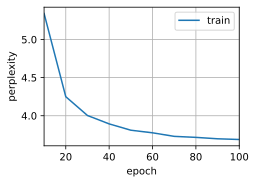

In [6]:
rnn_layer = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens, num_layers=num_layers)
model = util.model.RNNModel(rnn_layer, vocab_size).to(device)
util.train.train_ch8(model, train_iter, vocab, lr=lr, num_epochs=num_epochs, device=device)